
lambda = 1.0

Hamiltonian H =
[[ 0.8+0.j  0. +0.j  0. +0.j  0.2+0.j]
 [ 0. +0.j  0.4+0.j  0.2+0.j  0. +0.j]
 [ 0. +0.j  0.2+0.j  0.3+0.j  0. +0.j]
 [ 0.2+0.j  0. +0.j  0. +0.j -0.1+0.j]]

Exact eigenvalues of H:
E_0 = -0.14244289
E_1 = 0.14384472
E_2 = 0.55615528
E_3 = 0.84244289

Exact eigenvectors of H:
phi_0 = [-0.20759149+0.j  0.        +0.j  0.        +0.j  0.97821561+0.j]
phi_1 = [-0.        +0.j  0.61541221+0.j -0.78820544+0.j  0.        +0.j]
phi_2 = [ 0.        +0.j -0.78820544+0.j -0.61541221+0.j  0.        +0.j]
phi_3 = [-0.97821561+0.j  0.        +0.j  0.        +0.j -0.20759149+0.j]

Chosen eigenstate k = 0

Exact E_k = -0.14244289008980526

|phi_k> =
[-0.207591+0.j  0.      +0.j  0.      +0.j  0.978216+0.j]

PREP amplitudes =
[0.59160798 0.5        0.4472136  0.4472136 ]

Block encoding circuit:


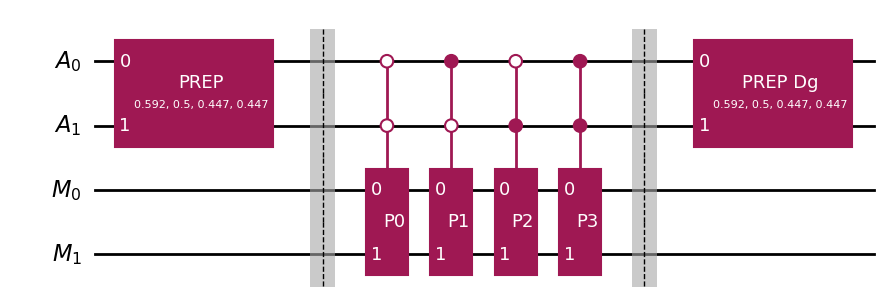


Shape of U_H = (16, 16)

<00|U_H|00> block =
[[ 0.8+0.j  0. -0.j  0. +0.j  0.2-0.j]
 [-0. +0.j  0.4-0.j  0.2-0.j  0. -0.j]
 [ 0. +0.j  0.2-0.j  0.3+0.j -0. -0.j]
 [ 0.2+0.j  0. +0.j -0. +0.j -0.1+0.j]]

H/lambda =
[[ 0.8+0.j  0. +0.j  0. +0.j  0.2+0.j]
 [ 0. +0.j  0.4+0.j  0.2+0.j  0. +0.j]
 [ 0. +0.j  0.2+0.j  0.3+0.j  0. +0.j]
 [ 0.2+0.j  0. +0.j  0. +0.j -0.1+0.j]]

Block encoding correct?  True

Shape of Q = (16, 16)

Is Q unitary?  True

Exact theta_k = 1.7137253626730549
Exact phase fraction theta/(2pi) = 0.27274786257136774

Complete QPE circuit:


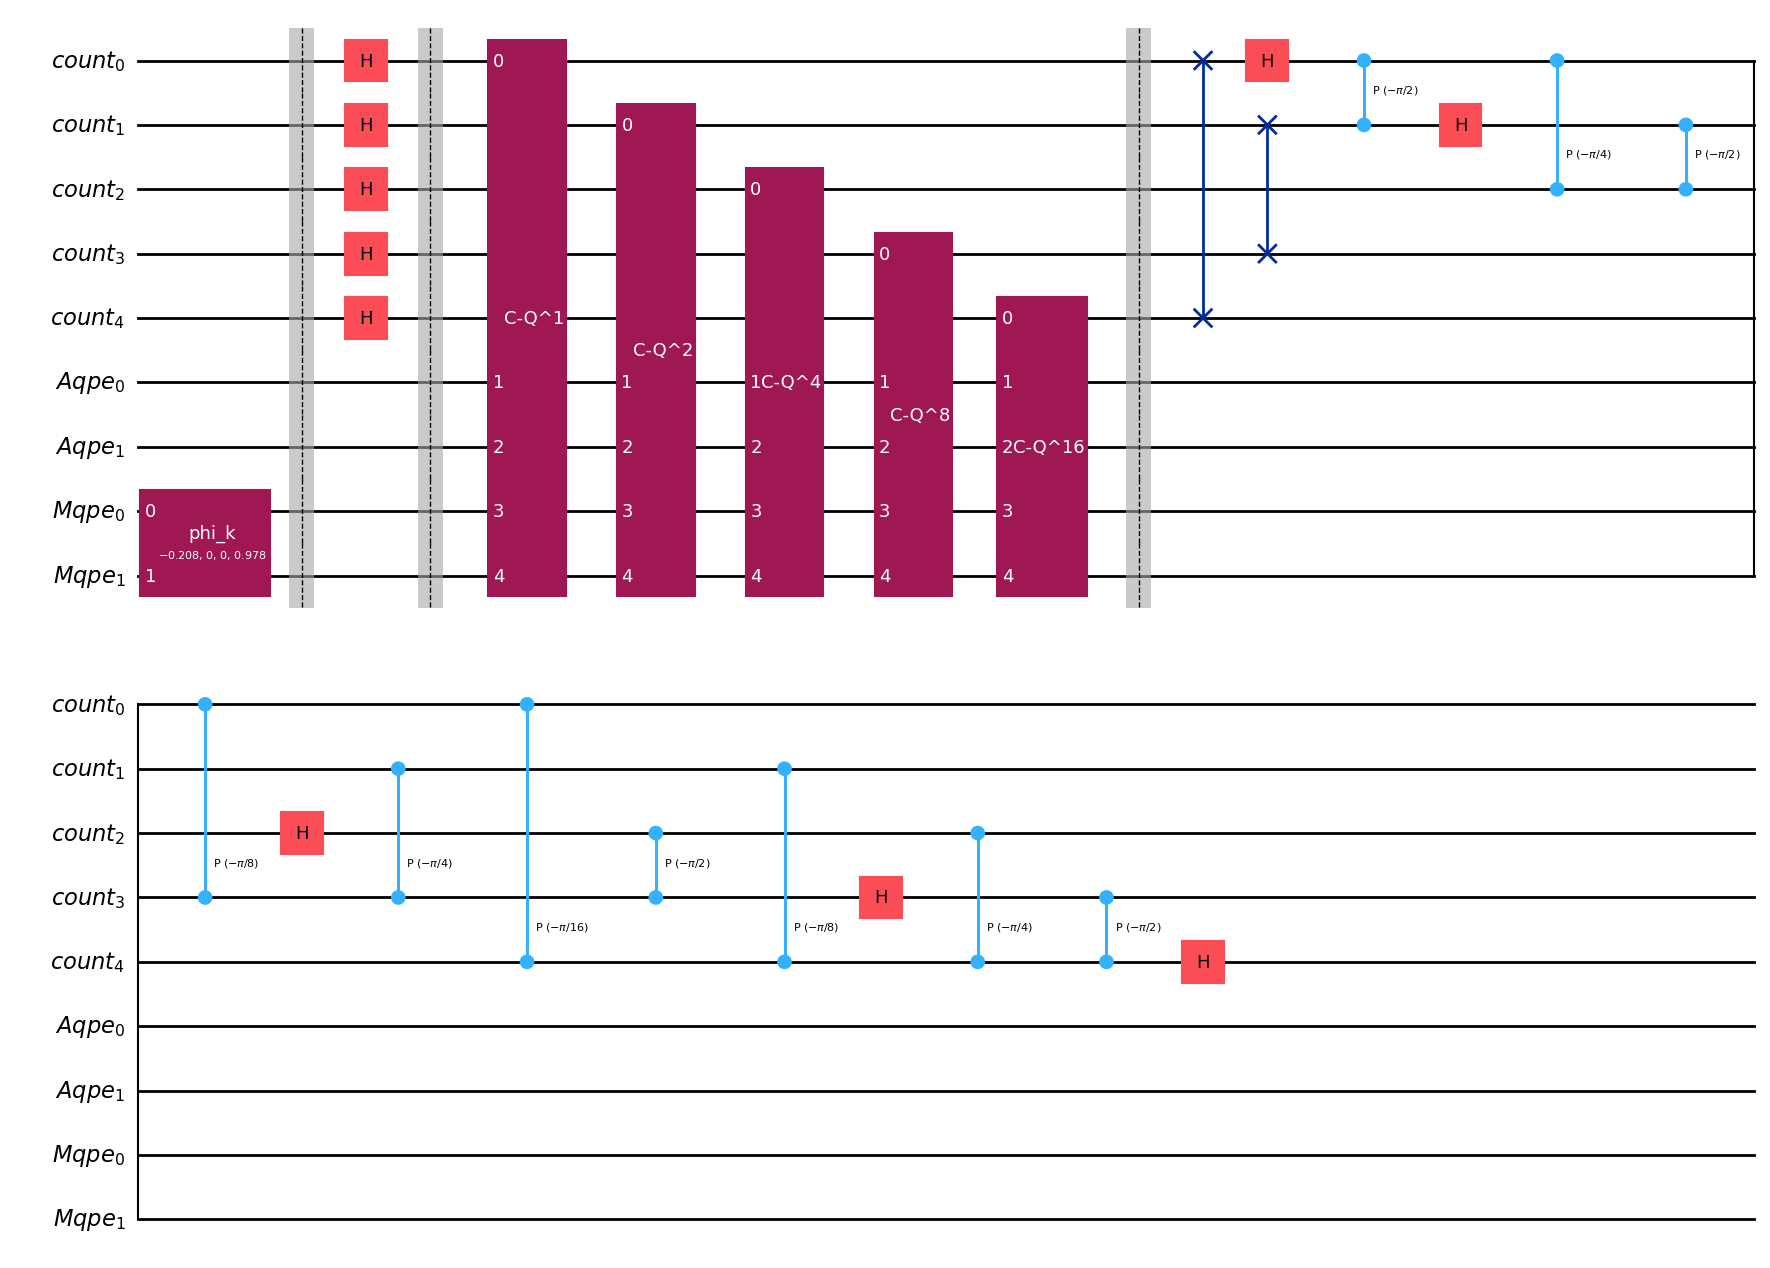


Most probable QPE outputs:
01001    probability = 0.3898798130876488
10111    probability = 0.38987981308764486
11000    probability = 0.054782664450703476
01000    probability = 0.054782664450703254
01010    probability = 0.018209113379447483
10110    probability = 0.01820911337944744
11001    probability = 0.010027570914580524
00111    probability = 0.0100275709145805
01011    probability = 0.0059972455986666735
10101    probability = 0.005997245598666671

Most probable measured binary = 01001
Probability = 0.3898798130876488

Measured phase fraction = 0.28125

Theta from QPE = 1.7671458676442586

            FINAL RESULT

Exact theta_k = 1.7137253626730549
QPE theta     = 1.7671458676442586

Exact E_k = -0.14244289008980526
QPE E_k   = -0.1950903220161282

Absolute energy error = 0.05264743192632293

SECOND QPE PEAK

Binary = 10111
Probability = 0.38987981308764486
Theta = 4.516039439535327
Energy = -0.19509032201612866


In [1]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import *
from qiskit.circuit.library import UnitaryGate, StatePreparation
from IPython.display import display
from numpy import pi
import numpy as np



# NUMBER OF QPE PRECISION BITS


bits_no = int(input("Enter the number of QPE precision bits: "))



# 1. BASIC PAULI MATRICES


I = np.eye(2, dtype=complex)

X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

Z = np.array([
    [1,  0],
    [0, -1]
], dtype=complex)



# 2. FOUR 2-QUBIT PAULI UNITARIES
#
# We choose:
#
# H = 0.35 II
#   + 0.25 ZI
#   + 0.20 IZ
#   + 0.20 XX
#


P0 = np.kron(I, I)
P1 = np.kron(Z, I)
P2 = np.kron(I, Z)
P3 = np.kron(X, X)

P_list = [
    P0,
    P1,
    P2,
    P3
]



# 3. COEFFICIENTS


beta = np.array([
    0.35,
    0.25,
    0.20,
    0.20
], dtype=float)


# lambda = sum beta_x

lam = np.sum(beta)

print("\nlambda =", lam)



# 4. CONSTRUCT HAMILTONIAN
#
# H = sum beta_x P_x


H = sum(
    beta[x] * P_list[x]
    for x in range(4)
)

print("\nHamiltonian H =")
print(np.round(H, 6))



# 5. FIND EXACT EIGENVALUES/EIGENVECTORS
#
# This classical diagonalization is ONLY for checking
# whether QPE gives the correct answer.


E_exact, phi_exact = np.linalg.eigh(H)

print("\nExact eigenvalues of H:")

for k in range(len(E_exact)):
    print(f"E_{k} = {E_exact[k]:.8f}")

print("\nExact eigenvectors of H:")

for k in range(len(phi_exact)):
    print(f"phi_{k} = {phi_exact[:, k]}")



# 6. CHOOSE THE EIGENSTATE WHOSE ENERGY WE WANT
#
# k = 0 --> ground state


k = 0

Ek_exact = E_exact[k]

phi_k = phi_exact[:, k]


print("\nChosen eigenstate k =", k)

print("\nExact E_k =", Ek_exact)

print("\n|phi_k> =")
print(np.round(phi_k, 6))



# 7. BUILD BLOCK ENCODING U_H
#
#
# U_H = PREP^dagger SEL PREP
#
#
# <00| U_H |00> = H/lambda
#



# 2 block-encoding ancilla qubits
anc = QuantumRegister(2, "A")

# 2 main qubits
main = QuantumRegister(2, "M")

U_BE = QuantumCircuit(
    anc,
    main,
    name="U_H"
)



# 8. PREP
#
# PREP|00>
#
# = sum_x sqrt(beta_x/lambda)|x>
#


prep_amplitudes = np.sqrt(
    beta / lam
)


print("\nPREP amplitudes =")
print(prep_amplitudes)


PREP = StatePreparation(
    prep_amplitudes,
    label="PREP"
)


U_BE.append(
    PREP,
    anc
)

U_BE.barrier()



# 9. SEL
#
# SEL |x>|psi>
#
# = |x> P_x |psi>
#


for x in range(4):

    Px_gate = UnitaryGate(
        P_list[x],
        label=f"P{x}"
    )

    controlled_Px = Px_gate.control(
        num_ctrl_qubits=2,
        ctrl_state=x
    )

    U_BE.append(
        controlled_Px,
        [
            anc[0],
            anc[1],
            main[0],
            main[1]
        ]
    )


U_BE.barrier()



# 10. PREP DAGGER


U_BE.append(
    PREP.inverse(),
    anc
)


print("\nBlock encoding circuit:")

display(
    U_BE.draw(output="mpl")
)



# 11. GET MATRIX OF BLOCK ENCODING


Umat = Operator(U_BE).data


print("\nShape of U_H =", Umat.shape)



# 12. VERIFY BLOCK ENCODING
#
# Qiskit basis ordering:
#
# |M1 M0 A1 A0>
#
# ancilla = 00 means last two bits = 00
#
# corresponding indices:
#
# 0000 -> 0
# 0100 -> 4
# 1000 -> 8
# 1100 -> 12
#


indices_A00 = [
    0,
    4,
    8,
    12
]


block00 = Umat[
    np.ix_(
        indices_A00,
        indices_A00
    )
]


print("\n<00|U_H|00> block =")
print(np.round(block00, 6))


print("\nH/lambda =")
print(np.round(H / lam, 6))


print(
    "\nBlock encoding correct? ",
    np.allclose(
        block00,
        H / lam
    )
)



# 13. CONSTRUCT REFLECTION R
#
#
# R = 2|00><00| - I
#
#
# on the ancilla register:
#
# |00> --> +|00>
# |01> --> -|01>
# |10> --> -|10>
# |11> --> -|11>
#


R_anc = np.diag([
     1,
    -1,
    -1,
    -1
]).astype(complex)


# Because Qiskit basis ordering is
#
# |main> tensor |ancilla>
#
# the full reflection is:
#
# I_main tensor R_anc

R_full = np.kron(
    np.eye(4),
    R_anc
)



# 14. QUBITIZATION WALK OPERATOR
#
#
# Q = R U_H
#


Qmat = R_full @ Umat


print("\nShape of Q =", Qmat.shape)


# check Q is unitary

print(
    "\nIs Q unitary? ",
    np.allclose(
        Qmat.conj().T @ Qmat,
        np.eye(16)
    )
)



# 15. EXACT THETA FOR COMPARISON
#
#
# cos(theta_k) = E_k/lambda
#


theta_exact = np.arccos(
    Ek_exact / lam
)


print("\nExact theta_k =", theta_exact)

print(
    "Exact phase fraction theta/(2pi) =",
    theta_exact / (2*pi)
)



# 16. QPE REGISTERS
#
#
# count register : bits_no qubits
#
# bottom Q register:
#
# 2 ancilla + 2 main qubits
#


count_reg = QuantumRegister(
    bits_no,
    "count"
)

A_reg = QuantumRegister(
    2,
    "Aqpe"
)

M_reg = QuantumRegister(
    2,
    "Mqpe"
)


qpe_circuit = QuantumCircuit(
    count_reg,
    A_reg,
    M_reg
)



# 17. PREPARE |phi_k> ON MAIN REGISTER
#
#
# Initial bottom state:
#
# |00>_A |phi_k>_M
#
#
# This is generally a superposition of
#
# |theta_k^+>
#
# and
#
# |theta_k^->
#


PHI = StatePreparation(
    phi_k,
    label="phi_k"
)


qpe_circuit.append(
    PHI,
    M_reg
)


qpe_circuit.barrier()



# 18. HADAMARD ON COUNTING REGISTER


for i in range(bits_no):

    qpe_circuit.h(
        count_reg[i]
    )


qpe_circuit.barrier()



# 19. CONTROLLED Q^(2^i)
#
#
# This replaces your old:
#
# cp(2*pi*theta*2^i)
#
#
# because now our unitary is the big Q.
#


for i in range(bits_no):

    power = 2**i


    
    # Calculate Q^(2^i)
    

    Q_power = np.linalg.matrix_power(
        Qmat,
        power
    )


    
    # Make controlled-Q^power matrix directly
    #
    # control qubit is the lowest-index qubit
    # in this local 5-qubit gate.
    #
    # For control = 0 --> identity
    #
    # For control = 1 --> Q_power
    #
    
    #
    # Local ordering:
    #
    # |target> |control>
    #
    # Therefore even indices correspond control=0,
    # odd indices correspond control=1.
    #
    

    CQ = np.zeros(
        (32, 32),
        dtype=complex
    )


    # control = 0
    for r in range(16):
        CQ[2*r, 2*r] = 1


    # control = 1
    for r in range(16):

        for c in range(16):

            CQ[
                2*r + 1,
                2*c + 1
            ] = Q_power[r, c]


    
    # turn matrix into gate
    

    CQ_gate = UnitaryGate(
        CQ,
        label=f"C-Q^{power}"
    )


    # append
    #
    # local order:
    #
    # control,
    # A0,A1,M0,M1
    

    qpe_circuit.append(
        CQ_gate,
        [
            count_reg[i],
            A_reg[0],
            A_reg[1],
            M_reg[0],
            M_reg[1]
        ]
    )


qpe_circuit.barrier()



# 20. INVERSE QFT
#
# SAME STRUCTURE AS YOUR QPE CODE



# SWAPS


for i in range(bits_no // 2):

    qpe_circuit.swap(
        count_reg[i],
        count_reg[
            bits_no - i - 1
        ]
    )



# INVERSE QFT


for i in range(bits_no):

    p = i

    for j in range(p):

        qpe_circuit.cp(
            -2*pi /
            (2**(p-j+1)),
            count_reg[j],
            count_reg[p]
        )

    qpe_circuit.h(
        count_reg[p]
    )


print("\nComplete QPE circuit:")

display(
    qpe_circuit.draw(
        output="mpl"
    )
)



# 21. DIRECT STATEVECTOR EVOLUTION
#
# NO AER
# NO TRANSPILATION
#


initial_state = Statevector.from_int(
    0,
    dims=2**qpe_circuit.num_qubits
)


final_state = initial_state.evolve(
    qpe_circuit
)



# 22. GET PROBABILITY DISTRIBUTION ONLY OF COUNT REGISTER


phase_qubits = list(
    range(bits_no)
)


phase_probabilities = (
    final_state.probabilities_dict(
        qargs=phase_qubits
    )
)



# 23. SORT RESULTS


sorted_results = sorted(
    phase_probabilities.items(),
    key=lambda item: item[1],
    reverse=True
)


print(
    "\nMost probable QPE outputs:"
)


for binary, probability in sorted_results[:10]:

    print(
        binary,
        "   probability =",
        probability
    )



# 24. MOST PROBABLE RESULT


measured_binary = sorted_results[0][0]

max_probability = sorted_results[0][1]


print(
    "\nMost probable measured binary =",
    measured_binary
)

print(
    "Probability =",
    max_probability
)



# 25. CONVERT BINARY FRACTION TO DECIMAL
#
#
# exactly like your original QPE code:
#
# binary b1 b2 ... bm means
#
# 0.b1 b2 ... bm
#


phase_fraction = 0.0


for i in range(bits_no):

    phase_fraction += (
        int(measured_binary[i])
        /
        (2**(i+1))
    )


print(
    "\nMeasured phase fraction =",
    phase_fraction
)



# 26. CONVERT PHASE FRACTION TO THETA
#
#
# eigenvalue:
#
# exp(2*pi*i*phase_fraction)
#
#
# therefore
#
# theta = 2*pi*phase_fraction
#


theta_qpe = (
    2*pi*phase_fraction
)


print(
    "\nTheta from QPE =",
    theta_qpe
)



# 27. ENERGY FROM THETA
#
#
# E_k = lambda cos(theta_k)
#


E_qpe = (
    lam * np.cos(theta_qpe)
)


print("\n======================================")
print("            FINAL RESULT")
print("======================================")


print(
    "\nExact theta_k =",
    theta_exact
)

print(
    "QPE theta     =",
    theta_qpe
)


print(
    "\nExact E_k =",
    Ek_exact
)

print(
    "QPE E_k   =",
    E_qpe
)

print(
    "\nAbsolute energy error =",
    abs(
        E_qpe - Ek_exact
    )
)



# 28. SHOW SECOND LARGE QPE PEAK TOO
#
# Because |00>|phi_k> is a superposition of
#
# theta_k and -theta_k branches.
#


if len(sorted_results) > 1:

    second_binary = (
        sorted_results[1][0]
    )

    second_probability = (
        sorted_results[1][1]
    )


    second_fraction = 0.0

    for i in range(bits_no):

        second_fraction += (
            int(second_binary[i])
            /
            (2**(i+1))
        )


    second_theta = (
        2*pi*second_fraction
    )


    second_energy = (
        lam *
        np.cos(second_theta)
    )


    print(
        "\n======================================"
    )

    print(
        "SECOND QPE PEAK"
    )

    print(
        "======================================"
    )


    print(
        "\nBinary =",
        second_binary
    )

    print(
        "Probability =",
        second_probability
    )

    print(
        "Theta =",
        second_theta
    )

    print(
        "Energy =",
        second_energy
    )